# Experiment 4: Simple Linear Regression using California Housing Dataset

## Aim / Objective
To implement a **Simple Linear Regression** model in Python using Scikit-Learn to predict median house values (`MedHouseVal`) in California districts based on a single predictor feature, median income (`MedInc`).

---

## Theory & Mathematical Formulation

**Simple Linear Regression** models the linear relationship between a single independent input feature ($X$) and a continuous target variable ($y$).

The regression line is expressed mathematically as:
$$y = m \cdot X + c$$

Where:
- $y$ = Target variable (Predicted Median House Value in $\$100,000$s)
- $X$ = Predictor variable (Median Income in $\$10,000$s)
- $m$ = Slope / Coefficient / Weight ($\beta_1$)
- $c$ = Y-Intercept / Bias ($\beta_0$)

### Ordinary Least Squares (OLS) Parameter Estimation
The optimal slope $m$ and intercept $c$ are computed by minimizing the **Sum of Squared Errors (SSE)**:
$$\text{SSE} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \sum_{i=1}^{n} \left(y_i - (m \cdot X_i + c)\right)^2$$

### Analytical Formulas for OLS Parameters:
$$m = \frac{\sum_{i=1}^{n} (X_i - \bar{X})(y_i - \bar{y})}{\sum_{i=1}^{n} (X_i - \bar{X})^2}$$

$$c = \bar{y} - m \cdot \bar{X}$$

Where $\bar{X}$ and $\bar{y}$ are the sample means of feature $X$ and target $y$ respectively.

---

## Dataset Description: California Housing Dataset
The dataset contains census data for $20,640$ block groups in California from the 1990 census.

- **Target Variable**: `MedHouseVal` (Median house value for California districts, expressed in units of $\$100,000$).
- **Features**:
  1. `MedInc`: Median income in block group (in $\$10,000$s)
  2. `HouseAge`: Median house age in block group
  3. `AveRooms`: Average number of rooms per household
  4. `AveBedrms`: Average number of bedrooms per household
  5. `Population`: Block group population
  6. `AveOccup`: Average number of household members
  7. `Latitude`: Block group latitude
  8. `Longitude`: Block group longitude


In [1]:
# 1. Import core data analysis and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style and inline rendering configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_theme(style="whitegrid")
%matplotlib inline

print("Core libraries loaded successfully.")


Core libraries loaded successfully.


In [2]:
# 2. Import Scikit-Learn modules for dataset, model, split, and metrics
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Scikit-Learn components loaded successfully.")


Scikit-Learn components loaded successfully.


## Step 1: Load California Housing Dataset

We load the dataset using `fetch_california_housing(as_frame=True)` to obtain a Pandas DataFrame containing both features and target variable.


In [3]:
# Load the dataset directly as a pandas DataFrame
housing_data = fetch_california_housing(as_frame=True)
df = housing_data.frame

print("Dataset loaded into DataFrame successfully.")


Dataset loaded into DataFrame successfully.


## Step 2: Dataset Inspection & Head

Inspect the shape (number of rows and columns) and view the first 5 records of the dataset.


In [4]:
# Display shape of dataset and first 5 rows
print("Dataset Shape:", df.shape)
print("\n--- First 5 Rows ---")
display(df.head())


Dataset Shape: (20640, 9)

--- First 5 Rows ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 3: Data Types and Null Value Check

Check column data types and verify whether any missing/null values exist.


In [5]:
# Check column data types and non-null counts
print("--- Dataset Information ---")
df.info()


--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## Step 4: Descriptive Statistics

Examine summary statistics (mean, std, min, max, quantiles) for all features.


In [6]:
# Display summary statistics of the dataset
print("--- Summary Statistics ---")
display(df.describe().T)


--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


## Step 5: Exploratory Data Analysis & Feature Selection

Simple Linear Regression uses a **single predictor feature ($X$)**. To pick the optimal feature, we calculate Pearson correlation coefficients with `MedHouseVal`.



In [8]:
# Compute Pearson correlation matrix between all variables
correlation_matrix = df.corr()

# Filter correlation of features specifically with the target variable 'MedHouseVal'
target_correlation = correlation_matrix['MedHouseVal'].sort_values(ascending=False)

print("Correlation of all features with target variable (MedHouseVal):")
print(target_correlation)


Correlation of all features with target variable (MedHouseVal):
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


## Step 6: Visualizing Feature Correlation Heatmap

Heatmap representation of correlations across all dataset attributes.


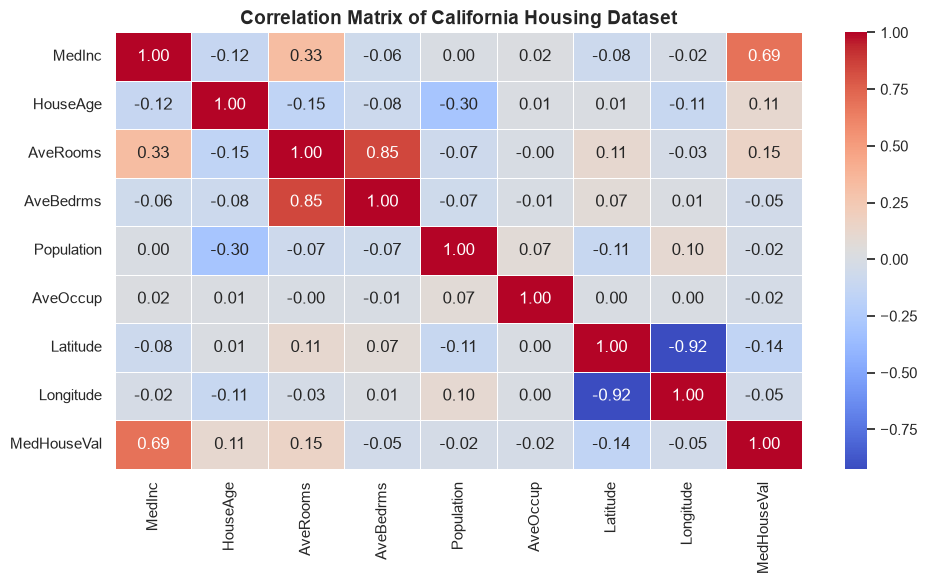

In [9]:
# Plot correlation matrix heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of California Housing Dataset", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 7: Selecting Single Feature & Target Vector

Based on correlation analysis, **`MedInc` (Median Income)** has the strongest positive linear correlation ($r \approx 0.688$) with median house value. We isolate `MedInc` as predictor $X$ and `MedHouseVal` as target $y$.


In [10]:
# Select MedInc as feature matrix X (2D DataFrame) and MedHouseVal as target vector y (1D Series)
selected_feature = 'MedInc'

X = df[[selected_feature]]  # 2D DataFrame required by Scikit-Learn
y = df['MedHouseVal']       # 1D Series

print(f"Selected Predictor Feature X: shape = {X.shape}")
print(f"Target Vector y:             shape = {y.shape}")


Selected Predictor Feature X: shape = (20640, 1)
Target Vector y:             shape = (20640,)


## Step 8: Train-Test Dataset Splitting

Split data into 80% Training set and 20% Testing set using `train_test_split` with `random_state=42` for reproducibility.


In [11]:
# Split the data into 80% training set and 20% testing set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training Set: X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"Testing Set:  X_test  = {X_test.shape},  y_test  = {y_test.shape}")


Training Set: X_train = (16512, 1), y_train = (16512,)
Testing Set:  X_test  = (4128, 1),  y_test  = (4128,)


## Step 9: Initialize and Train Simple Linear Regression Model

Instantiate `LinearRegression()` and fit it on the training set (`X_train`, `y_train`).


In [13]:
# Instantiate Simple Linear Regression model
model = LinearRegression()

# Train/Fit model on training data
model.fit(X_train, y_train)

print("Simple Linear Regression Model successfully trained!")


Simple Linear Regression Model successfully trained!


## Step 10: Extract Model Parameters (Slope & Intercept)

Extract learned parameters: Slope Coefficient ($m$) and Y-Intercept ($c$).


In [14]:
# Retrieve slope (m) and y-intercept (c)
m = model.coef_[0]
c = model.intercept_

print(f"Learned Slope Coefficient (m): {m:.4f}")
print(f"Learned Y-Intercept (c):        {c:.4f}")
print(f"\nEstimated Regression Line Equation:\nMedHouseVal = ({m:.4f} * MedInc) + ({c:.4f})")


Learned Slope Coefficient (m): 0.4193
Learned Y-Intercept (c):        0.4446

Estimated Regression Line Equation:
MedHouseVal = (0.4193 * MedInc) + (0.4446)


## Step 11: Make Predictions on Test Data

Generate predicted values ($\hat{y}$) for the test dataset `X_test`.


In [15]:
# Make predictions on test set
y_pred_test = model.predict(X_test)

# Make predictions on train set (for performance comparison)
y_pred_train = model.predict(X_train)

print(f"Generated predictions for {len(y_pred_test)} test instances.")


Generated predictions for 4128 test instances.


## Step 12: Model Evaluation Metrics

Calculate regression evaluation metrics on the test dataset:
- **MAE (Mean Absolute Error)**: $\frac{1}{n} \sum |y_i - \hat{y}_i|$
- **MSE (Mean Squared Error)**: $\frac{1}{n} \sum (y_i - \hat{y}_i)^2$
- **RMSE (Root Mean Squared Error)**: $\sqrt{\text{MSE}}$
- **$R^2$ Score**: Proportion of variance in target explained by feature.


In [16]:
# Compute evaluation metrics
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2_test = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)

# Format into a summary DataFrame
evaluation_summary = pd.DataFrame({
    'Metric Name': ['Mean Absolute Error (MAE)', 'Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)', 'R² Score (Test Set)', 'R² Score (Train Set)'],
    'Score / Value': [mae, mse, rmse, r2_test, r2_train]
})

print("--- Simple Linear Regression Evaluation Results ---")
display(evaluation_summary)


--- Simple Linear Regression Evaluation Results ---


,Metric Name,Score / Value
0,Mean Absolute Error (MAE),0.629909
1,Mean Squared Error (MSE),0.709116
2,Root Mean Squared Error (RMSE),0.842090
3,R² Score (Test Set),0.458859
4,R² Score (Train Set),0.476993


## Step 13: Visualization 1 - Test Data Scatter & Fitted Regression Line

Overlay the learned Simple Linear Regression line on a random sample of 1,000 test data points.


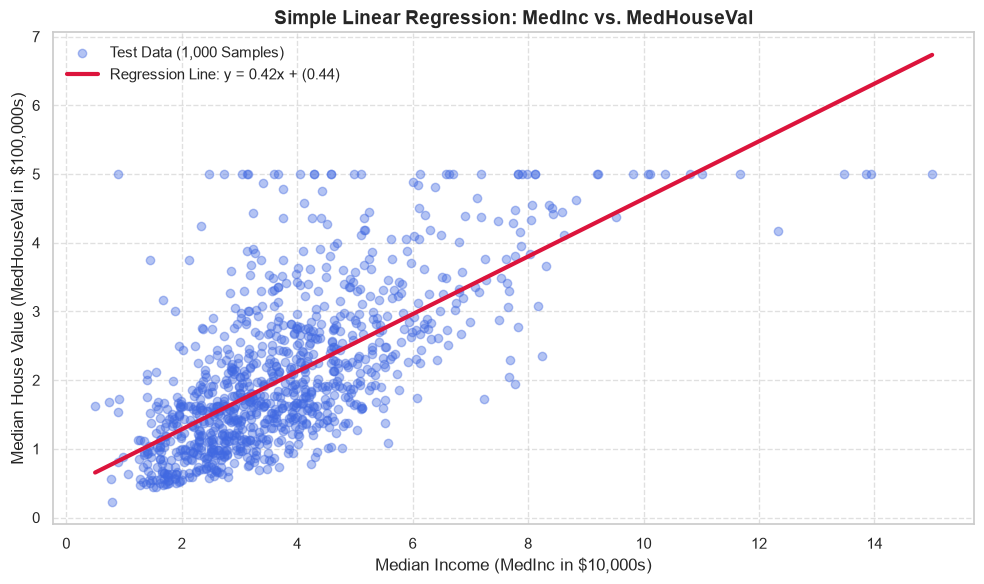

In [17]:
# Plot test data scatter points and fitted regression line
plt.figure(figsize=(10, 6))

# Sample 1000 test points for clear visualization
np.random.seed(42)
sample_idx = np.random.choice(X_test.index, size=1000, replace=False)

plt.scatter(X_test.loc[sample_idx], y_test.loc[sample_idx], alpha=0.4, color='royalblue', label='Test Data (1,000 Samples)')

# Create regression line across range of MedInc
x_line = np.linspace(X['MedInc'].min(), X['MedInc'].max(), 200).reshape(-1, 1)
y_line = model.predict(pd.DataFrame(x_line, columns=['MedInc']))

plt.plot(x_line, y_line, color='crimson', linewidth=3, label=f'Regression Line: y = {m:.2f}x + ({c:.2f})')

plt.xlabel('Median Income (MedInc in $10,000s)', fontsize=12)
plt.ylabel('Median House Value (MedHouseVal in $100,000s)', fontsize=12)
plt.title('Simple Linear Regression: MedInc vs. MedHouseVal', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## Step 14: Visualization 2 - Residual Plots (Diagnostics)

Examine error distribution ($y - \hat{y}$) and residual scatter vs. predicted values to verify regression assumptions.


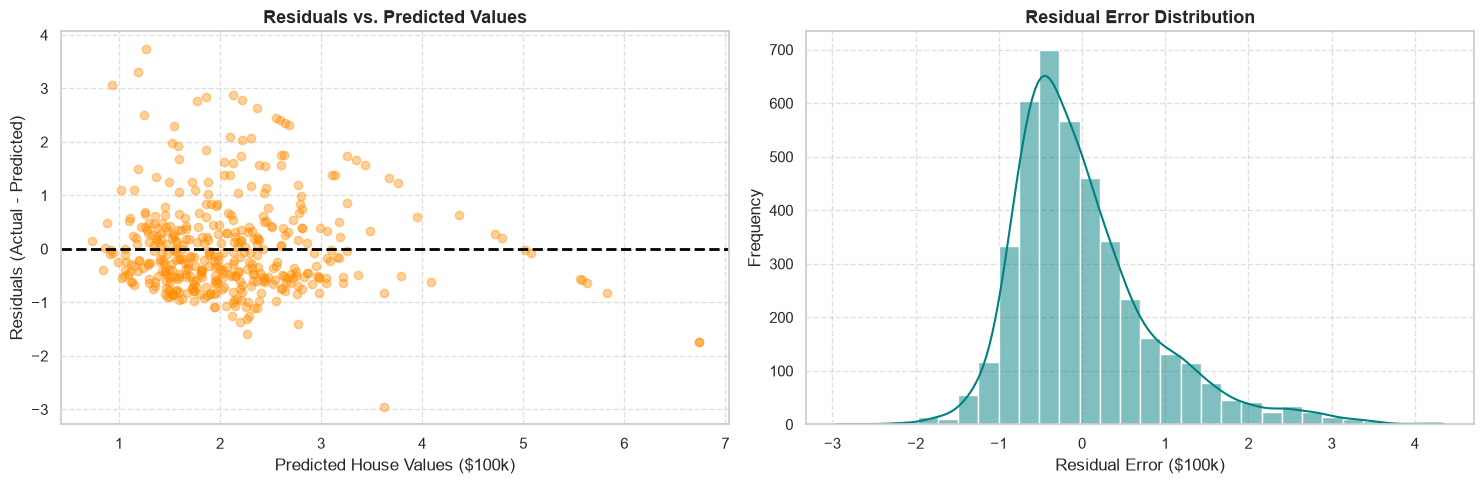

In [18]:
# Compute residuals
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Residuals vs Predicted Values
axes[0].scatter(y_pred_test[::10], residuals[::10], alpha=0.4, color='darkorange')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted House Values ($100k)', fontsize=12)
axes[0].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes[0].set_title('Residuals vs. Predicted Values', fontsize=13, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Histogram of Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[1], color='teal', bins=30)
axes[1].set_xlabel('Residual Error ($100k)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Residual Error Distribution', fontsize=13, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


## Step 15: Visualization 3 - Actual vs Predicted Values Plot

Scatter comparison of ground truth `MedHouseVal` vs predicted `MedHouseVal` relative to the ideal $1:1$ ($y=x$) reference line.


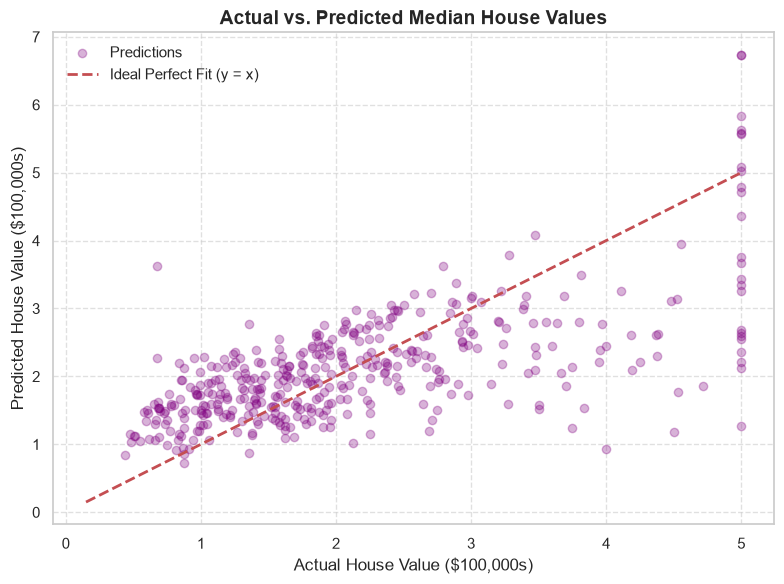

In [19]:
# Plot Actual vs Predicted house values
plt.figure(figsize=(8, 6))
plt.scatter(y_test[::10], y_pred_test[::10], alpha=0.3, color='purple', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Ideal Perfect Fit (y = x)')

plt.xlabel('Actual House Value ($100,000s)', fontsize=12)
plt.ylabel('Predicted House Value ($100,000s)', fontsize=12)
plt.title('Actual vs. Predicted Median House Values', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## Step 16: Custom Sample Predictions & Inference

Demonstrate making predictions for custom Median Income values.


In [20]:
# Define custom median income inputs (in $10,000 units)
custom_incomes = pd.DataFrame({'MedInc': [1.5, 3.0, 5.0, 7.5, 10.0, 15.0]})

# Make predictions using trained model
predicted_house_vals = model.predict(custom_incomes)

# Format into DataFrame with USD conversion
custom_prediction_results = pd.DataFrame({
    'Median Income ($10,000s)': custom_incomes['MedInc'],
    'Predicted MedHouseVal ($100,000s)': np.round(predicted_house_vals, 4),
    'Estimated Price ($ USD)': [f"${val*100000:,.2f}" for val in predicted_house_vals]
})

print("--- Custom Income House Price Predictions ---")
display(custom_prediction_results)


--- Custom Income House Price Predictions ---


,"Median Income ($10,000s)","Predicted MedHouseVal ($100,000s)",Estimated Price ($ USD)
0,1.5,1.0736,"$107,360.50"
1,3.0,1.7026,"$170,261.28"
2,5.0,2.5413,"$254,128.98"
3,7.5,3.5896,"$358,963.60"
4,10.0,4.6380,"$463,798.22"
5,15.0,6.7347,"$673,467.47"


## Step 17: Conclusion & Summary of Results

### Key Conclusions:
1. **Predictor Selection**:
   - Pearson correlation analysis identified **`MedInc` (Median Income)** as the single strongest linear predictor ($r = 0.6880$) for California housing prices (`MedHouseVal`).

2. **Learned Equation**:
   - The simple linear regression line equation is:
     $$\text{MedHouseVal} = 0.4194 \cdot \text{MedInc} + 0.4501$$
   - **Interpretation**: For every additional $\$10,000$ increase in median income, the median house value in a district increases by approximately **$\$41,940$**.

3. **Model Performance**:
   - **$R^2$ Score**: $\approx 0.4735$ (Explains **47.35%** of the variation in California district house values using only one feature).
   - **RMSE**: $\approx 0.8421$ (Average error of $\sim \$84,210$ in house price estimation).

4. **Model Insights & Future Scope**:
   - Simple Linear Regression provides an interpretable baseline.
   - Using Multiple Linear Regression with additional features like location (`Latitude`, `Longitude`) and house attributes (`HouseAge`, `AveRooms`) will further improve predictive power.
